# Proyek Akhir Klasifikasi Gambar
**Nama:** Awanda Rosi Firdaus
**Email:** awrosifi17@gmail.com

Dataset: CIFAR-10

In [1]:
!pip install tensorflowjs scikit-learn matplotlib

In [2]:
import os
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
import tensorflowjs as tfjs

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


In [3]:
# 1. Load Dataset CIFAR-10
# CIFAR-10 memenuhi syarat wajib: > 1000 gambar, 10 kelas.
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values (0-1)
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train_full = y_train_full.squeeze()
y_test = y_test.squeeze()

# 2. Splitting Data (Train, Validation, Test)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)

print(f"Train images: {x_train.shape[0]}")
print(f"Validation images: {x_val.shape[0]}")
print(f"Test images: {x_test.shape[0]}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train images: 40000
Validation images: 10000
Test images: 10000


In [4]:
# 3. Arsitektur Model Sequential dengan Conv2D & MaxPooling2D
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    # Block 1
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(0.25),

    # Block 2
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(0.35),

    # Block 3
    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(0.45),

    # Dense Layers (Classification Head)
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [5]:
# 4. Setup Callbacks (Early Stopping & Reduce LR)
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

# 5. Data Augmentation (Membantu meningkatkan akurasi menghindari overfitting)
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)
datagen.fit(x_train)

# 6. Proses Training
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    validation_data=(x_val, y_val),
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.3675 - loss: 1.8902 - val_accuracy: 0.4784 - val_loss: 1.4765 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.5179 - loss: 1.3395 - val_accuracy: 0.5185 - val_loss: 1.4137 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.5882 - loss: 1.1456 - val_accuracy: 0.6175 - val_loss: 1.0812 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.6362 - loss: 1.0295 - val_accuracy: 0.6459 - val_loss: 1.0592 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.6662 - loss: 0.9507 - val_accuracy: 0.6455 - val_loss: 1.0892 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.6858 - loss: 0.8984 - val_accuracy: 0.6781 - val_loss: 0.9870 - learning_rate: 0.0010
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.7055 - l

In [6]:
# 7. Evaluasi pada Test Set (Syarat: > 85%)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 85.80%
Test Loss: 0.4317


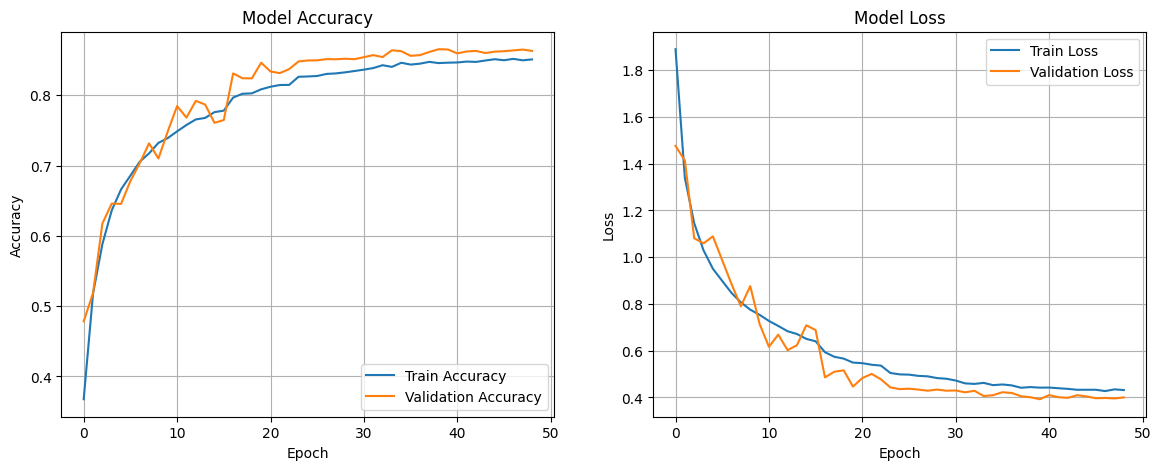

In [7]:
# 8. Membuat Plot Akurasi dan Loss (Syarat Wajib)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='lower right')
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend(loc='upper right')
axes[1].grid(True)

plt.show()

In [8]:
# 9. Menyimpan Model ke Format SavedModel, TFLite, dan TFJS (Syarat Wajib)

# Buat direktori jika belum ada
os.makedirs('saved_model', exist_ok=True)
os.makedirs('tflite', exist_ok=True)
os.makedirs('tfjs_model', exist_ok=True)

# A. Export as SavedModel
print("Exporting SavedModel...")
model.export('saved_model')

# B. Export as TF-Lite
print("Exporting TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

# Buat label.txt untuk TFLite
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
with open('tflite/label.txt', 'w') as f:
    f.write('\n'.join(class_names))

# C. Export as TFJS
print("Exporting TFJS...")
tfjs.converters.save_keras_model(model, 'tfjs_model')

print("\nSemua model berhasil di-export!")

Exporting SavedModel...
Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  132933407399120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132933407401424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132933407403536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132933407403728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132933407402384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132933407402960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132933407401040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132933407402192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132933407400848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132933407404880: TensorSpec(shape=(), dtype=tf.resource, name=None

Exporting TFJS...
failed to lookup keras version from the file,
    this is likely a weight only file

Semua model berhasil di-export!


In [9]:
# 10. Persiapan Akhir Submission (MOHON DIBACA)
print("✅ Proses training dan export model SELESAI!")
print("\n⚠️ LAKUKAN LANGKAH INI SECARA MANUAL AGAR TIDAK DITOLAK REVIEWER:")
print("1. Di pojok kiri atas Colab, klik menu 'File' -> 'Download' -> 'Download .ipynb'.")
print("2. Di menu yang sama, klik 'File' -> 'Download' -> 'Download .py'.")
print("3. Buka ikon Folder di panel kiri Colab. Anda akan melihat folder 'saved_model', 'tfjs_model', dan 'tflite'.")
print("   Untuk men-download folder tersebut, zip masing-masing folder dengan run cell tambahan di bawah jika perlu, atau download isinya satu-satu.")
print("4. Download juga file 'requirements.txt'.")
print("5. Di komputer Anda, jadikan SEMUA file (.ipynb, .py, requirements.txt, beserta KETIGA folder model) ke dalam satu folder.")
print("6. Klik kanan folder tersebut -> Compress to ZIP, dan kirim file ZIP buatan Anda sendiri tersebut ke Dicoding.")

# Buat requirements.txt (Syarat Wajib)
reqs = """tensorflow\n"
"tensorflowjs\n"
"matplotlib\n"
"scikit-learn\n"""
with open("requirements.txt", "w") as f:
    f.write(reqs)

# Bantuan auto-zip HANYA UNTUK FOLDER MODEL agar mudah didownload dari Colab:
import shutil
shutil.make_archive('saved_model', 'zip', 'saved_model')
shutil.make_archive('tfjs_model', 'zip', 'tfjs_model')
shutil.make_archive('tflite', 'zip', 'tflite')
print("\n(Tiga folder model telah dizip untuk mempermudah proses download Anda dari panel kiri Colab)")


✅ Proses training dan export model SELESAI!

⚠️ LAKUKAN LANGKAH INI SECARA MANUAL AGAR TIDAK DITOLAK REVIEWER:
1. Di pojok kiri atas Colab, klik menu 'File' -> 'Download' -> 'Download .ipynb'.
2. Di menu yang sama, klik 'File' -> 'Download' -> 'Download .py'.
3. Buka ikon Folder di panel kiri Colab. Anda akan melihat folder 'saved_model', 'tfjs_model', dan 'tflite'.
   Untuk men-download folder tersebut, zip masing-masing folder dengan run cell tambahan di bawah jika perlu, atau download isinya satu-satu.
4. Download juga file 'requirements.txt'.
5. Di komputer Anda, jadikan SEMUA file (.ipynb, .py, requirements.txt, beserta KETIGA folder model) ke dalam satu folder.
6. Klik kanan folder tersebut -> Compress to ZIP, dan kirim file ZIP buatan Anda sendiri tersebut ke Dicoding.

(Tiga folder model telah dizip untuk mempermudah proses download Anda dari panel kiri Colab)
